# 2.4.2 Visualization Utilities

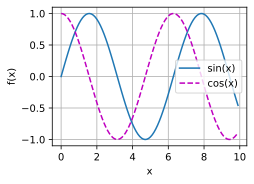

In [3]:
import numpy as np
from matplotlib_inline import backend_inline
from matplotlib import pyplot as plt
import torch

def use_svg_display(): 
    """Plot using SVG format."""
    backend_inline.set_matplotlib_formats("svg")

def set_figsize(figsize=(3.5, 2.5)):
    """Set the figure size for matplotlib."""
    use_svg_display()
    plt.rcParams['figure.figsize'] = figsize

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Set the axes for matplotlib."""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()


#@save
def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """Plot data points."""

    def has_one_axis(X):  # True if X (tensor or list) has 1 axis
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X): X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)

    set_figsize(figsize)
    if axes is None:
        axes = plt.gca()  
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        axes.plot(x,y,fmt) if len(x) else axes.plot(y,fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

if __name__ == '__main__':
    x = np.arange(0, 10, 0.1)
    y1 = np.sin(x) 
    y2 = np.cos(x) 
    
    plot(X=x, Y=[y1, y2], xlabel='x', ylabel='f(x)', legend=['sin(x)', 'cos(x)'])
    
    plt.show()

# Exercises

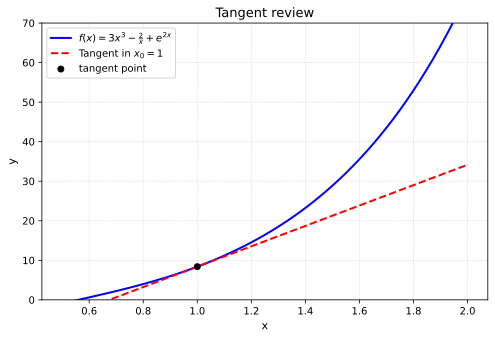

In [4]:
x=torch.linspace(0.5,2.0,500)
y_f=3*x**3-2/x+torch.exp(2*x)

x0=1.0
e2=np.exp(2)
y0=1.0+e2
m=11.0+2*e2

y_t=y0+m*(x-x0)

plt.figure(figsize=(8,5))
plt.plot(x.numpy(),y_f.numpy(),label=r"$f(x)=3x^3- \frac{2}{x} + e^{2x}$",color="blue",linewidth=2)
plt.plot(x.numpy(), y_t.numpy(), label=r"Tangent in $x_0=1$", color="red", linestyle="--", linewidth=2)
plt.scatter([x0],[y0],color="black",zorder=5,label=f"tangent point")

plt.title("Tangent review",fontsize=13)
plt.xlabel("x", fontsize=11)
plt.ylabel("y", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)
plt.ylim(0, 70)
plt.show()


In [ ]:
import simpy as sp

x1=sp.symbols('x1')
x2=sp.symbols('x2')
f=x1**2+x2+torch.sin(x1+x2)+3*x2^3